In [1]:
import os
import amigo
from astropy.io import fits
from matplotlib import pyplot as plt
from jax import numpy as np
import jax

In [2]:
uncal_path = "/Users/mcha5804/JWST/FLATS/uncal/"
data_path = "/Users/mcha5804/JWST/FLATS/calslope/"

# Get the list of files in the directory
files = os.listdir(uncal_path)
# files = files[0:2]

1ints, 30groups, NIS_LAMP, F380M


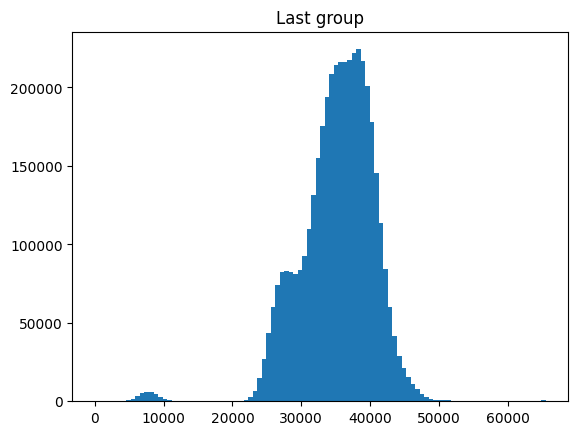

1ints, 20groups, NIS_LAMP, F444W
1ints, 45groups, NIS_LAMP, CLEAR
1ints, 30groups, NIS_LAMP, F480M
1ints, 30groups, NIS_LAMP, F480M
1ints, 16groups, NIS_IMAGE, F430M
1ints, 16groups, NIS_IMAGE, F430M
1ints, 20groups, NIS_LAMP, CLEAR
1ints, 20groups, NIS_LAMP, CLEAR
1ints, 16groups, NIS_IMAGE, F430M
1ints, 45groups, NIS_LAMP, CLEAR
1ints, 30groups, NIS_LAMP, F480M
1ints, 45groups, NIS_LAMP, CLEAR
1ints, 30groups, NIS_LAMP, F480M
1ints, 20groups, NIS_LAMP, CLEAR
1ints, 20groups, NIS_LAMP, CLEAR
1ints, 20groups, NIS_LAMP, F444W
1ints, 16groups, NIS_IMAGE, F430M
1ints, 30groups, NIS_LAMP, F430M
1ints, 16groups, NIS_IMAGE, F430M
1ints, 25groups, NIS_LAMP, CLEAR
1ints, 16groups, NIS_IMAGE, F430M
1ints, 16groups, NIS_IMAGE, F430M
1ints, 20groups, NIS_LAMP, F277W
1ints, 25groups, NIS_LAMP, CLEAR
1ints, 30groups, NIS_LAMP, F380M
1ints, 20groups, NIS_LAMP, CLEAR
1ints, 30groups, NIS_LAMP, F430M
1ints, 16groups, NIS_IMAGE, F430M
1ints, 30groups, NIS_LAMP, F430M
1ints, 20groups, NIS_LAMP, CLEAR
1i

In [3]:
plot_me = True
special_files = []

for file in files:
    try:
        f = fits.open(uncal_path + file)
    except:
        # print(f"Error reading {file}")
        continue

    # if f[0].header["EXP_TYPE"] != "NIS_LAMP":
    #     continue
    # if f[0].header["NGROUPS"] != 20:
    #     continue
    # if f[0].header["NGROUPS"] != 45:
    #     continue
    # if f[0].header["FILTER"] != "CLEAR":
    #     continue
    # if f[0].header["FILENAME"] != "jw04472014001_01201_00001_nis_uncal.fits":
    #     continue

    print(
        f"{f[0].header['NINTS']}ints, {f[0].header['NGROUPS']}groups, {f[0].header['EXP_TYPE']}, {f[0].header['FILTER']}"
    )
    # print(file)
    special_files.append(f)

    if plot_me:
        plot_me = False

        # Plot the data
        data = f["SCI"].data
        # plt.imshow(data[0][-1], cmap="viridis", origin="lower")
        plt.hist(data[0][-1].flatten(), bins=100)
        # plt.colorbar()
        plt.title("Last group")
        plt.show()

In [4]:
from itertools import groupby
import operator

group_keys = ["NGROUPS", "EXP_TYPE", "FILTER"]

file_data = []
for file in files:
    try:
        f = fits.open(uncal_path + file)
    except:
        continue

    key_values = tuple(str(f[0].header.get(key)) for key in group_keys)
    file_data.append((key_values, f[0].header["FILENAME"]))

# Sort and group by the extracted key values
file_data.sort(key=operator.itemgetter(0))

sorted_groups = {
    k: list(map(operator.itemgetter(1), v))
    for k, v in groupby(file_data, key=operator.itemgetter(0))
}

In [6]:
for key, files in sorted_groups.items():
    print(key, len(files))

('10', 'NIS_LAMP', 'CLEAR') 11
('16', 'NIS_IMAGE', 'F430M') 51
('20', 'NIS_LAMP', 'CLEAR') 33
('20', 'NIS_LAMP', 'F277W') 10
('20', 'NIS_LAMP', 'F356W') 10
('20', 'NIS_LAMP', 'F444W') 10
('25', 'NIS_LAMP', 'CLEAR') 11
('30', 'NIS_LAMP', 'F380M') 10
('30', 'NIS_LAMP', 'F430M') 10
('30', 'NIS_LAMP', 'F480M') 10
('45', 'NIS_LAMP', 'CLEAR') 11


In [7]:
def full_to_SUB80_groups(data):

    # applying full_to_SUB80
    sub80 = jax.vmap(amigo.misc.full_to_SUB80)(data.reshape(-1, 2048, 2048))
    sub80 = sub80.reshape(data.shape[0], data.shape[1], 80, 80)

    return sub80


def full_to_SUB80_files(files: list, filename_out: str):

    sub80s = []
    for f in files:
        # grabbing data from file
        data = np.array(f["SCI"].data)

        # applying full_to_SUB80
        sub80 = full_to_SUB80_groups(data)

        # appending to list for later stacking
        sub80s.append(sub80)

    # stacking integrations
    sub80s = np.stack(sub80s, axis=0).squeeze(axis=1)

    # Copying header information
    stacked_file = files[0]
    stacked_file["SCI"].data = sub80s
    stacked_file[0].header["NINTS"] = sub80s.shape[0]
    stacked_file.writeto(filename_out, overwrite=True)

In [19]:
from tqdm.notebook import tqdm as tqdm

save_dir = "/Users/mcha5804/JWST/FLATS/uncal_stacks/"

for identifiers, filenames in tqdm(sorted_groups.items()):

    files = []
    for filename in filenames:
        file = fits.open(uncal_path + filename)
        files.append(file)

    full_to_SUB80_files(files, save_dir + "_".join(identifiers) + "_uncal.fits")

  0%|          | 0/11 [00:00<?, ?it/s]

In [9]:
# keys = list(special_files[0][0].header.keys())

# f0 = special_files[0]
# for key in keys:
#     for f in special_files:
#         if f0[0].header[key] != f[0].header[key]:
#             print(key)
#             continue

#         # print()

In [10]:
import os
import shutil
import jax.numpy as np
from astropy.io import fits
from amigo.misc import tqdm
from amigo.pipelines import *


def process_calslope(
    directory,
    output_dir="calslope/",
    sigma=5,
    chunk_size=0,
    n_groups=None,  # how many groups of the ramp to use
    clean_dir=True,
):
    """
    Chunk size determines the maximum number of integrations in a 'chunk'. Each chunk
    is saved to its own file with an integer extension added. This breaks the data set
    into smaller time series to help avoid issues with any time-variation in the data.
    A chunk_size of zero will do no chunking and process the data all in one.

    This will (presently) always reprocess data

    if clean_dir is True, the existisng contents of the output_dir will be deleted prior
    to procesing, so ensure no old files are hanging around
    """
    if directory[-1] != "/":
        directory += "/"
    if output_dir[-1] != "/":
        output_dir += "/"

    # Get the files
    files = [directory + f for f in os.listdir(directory) if f.endswith("_uncal.fits")]

    # Check if there are any files to process
    if len(files) == 0:
        print("No _ramp.fits files found, no processing done.")
        return

    # Get the file paths
    paths = files[0].split("/")
    base_path = "/".join(paths[:-2]) + "/"
    output_path = base_path + output_dir

    # Check whether the specified output directory exists
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    # Clear the existing files (since we might use different chunk sizes, and we do not
    # want to have old files hang around)
    if clean_dir:
        print("Cleaning existing directory")
        delete_contents(output_path)

    # Iterate over files
    print("Running calslope processing...")
    for file_path in tqdm(files):

        file = fits.open(file_path)

        # Check if the file is a NIS_AMI file
        if file[0].header["EXP_TYPE"] not in ["NIS_AMI", "NIS_LAMP", "NIS_IMAGE"]:
            print("Not a supported file type, skipping...")
            continue

        # Skip single group files
        if file[0].header["NGROUPS"] == 1:
            print("Only one group, skipping...")
            continue

        # Get the data
        data = np.array(file["SCI"].data, int)

        # Copying header information
        sci_header = file["SCI"].header.copy(strip=True)
        sci_header.remove("EXTNAME")

        file.close()

        if chunk_size == 0:
            chunks = [data]
            nchunks = 1
        else:
            nints = data.shape[0]
            if nints < chunk_size:
                nchunks = 1
            else:
                nchunks = np.round(nints / chunk_size).astype(int)
            chunks = np.array_split(data, nchunks)
            print(f"Breaking into {nchunks} chunks")

        # Get the root of the file name
        file_name = file_path.split("/")[-1]
        file_root = "_".join(file_name.split("_")[:-2])

        for i, chunk in enumerate(chunks):

            # Check if the file is a NIS_AMI file
            file_name = file_root + f"_{i+1:0{4}}" + "_nis_calslope.fits"
            file_calslope = os.path.join(output_path + file_name)

            # Create the new file
            shutil.copy(file_path, file_calslope)

            # Open new file
            # file = fits.open(file_calslope, mode="update")
            file = fits.open(file_calslope)

            # Remove the redundant or undesired extensions
            del file["SCI"]
            del file["GROUP"]
            del file["INT_TIMES"]

            # Update the various headers
            file[0].header["NCHUNKS"] = int(nchunks)
            file[0].header["CHUNK"] = i + 1
            file[0].header["CHUNKSZ"] = int(chunk_size)
            file[0].header["NINTS"] = int(chunk.shape[0])
            file[0].header["FILENAME"] = file_name
            file[0].header["SIGMA"] = sigma
            file[0].header.extend(sci_header)  # Copy the science header

            # Process the chunk
            file = process_data(file, chunk, sigma=sigma)

            # Save as calslope
            file.writeto(file_calslope, overwrite=True)
            file.close()

    print("Done\n")
    return output_path